## Imports and Configs

In [1]:
!python -c "import monai" || pip install -q "monai[nibabel, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
!python -c "import onnxruntime" || pip install -q onnxruntime
!pip install -q SimpleITK-SimpleElastix
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.7 MB/s eta 0:00:00
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'onnxruntime'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 13.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import torch
import torch.nn as nn
import monai
from monai.networks.nets import UNet, DynUNet, SwinUNETR
from monai.networks.layers import Norm
from monai.losses import DiceLoss, DiceCELoss, DiceFocalLoss
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose,
    LoadImage,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    CropForegroundd,
    RandFlip,
    RandRotate90,
    RandShiftIntensityd,
    ToTensor,
    Spacing,
    EnsureChannelFirst,
    ScaleIntensity,
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    EnsureTyped,
    EnsureType,
    MapTransform,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandCropByLabelClassesd,
    Resize,
    Resized,
    ToTensord,
    RandRotate90d,
    RandFlipd,
    ScaleIntensityRange,
)
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import nibabel as nib
from glob import glob
import torch
from monai.utils import set_determinism
import onnxruntime
from tqdm import tqdm
import SimpleITK as sitk
from monai.transforms import MapTransform
import os
from monai.data import DataLoader, decollate_batch, CacheDataset,Dataset
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau



In [4]:
# # Set deterministic training for reproducibility
# set_determinism(seed=42)
# os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# # Set CUDA device order
# torch.backends.cudnn.benchmark = True
# root_dir = "/content/drive/MyDrive/projects/MISA"

In [5]:
root_dir = "/content/drive/MyDrive/projects/MISA"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Data Preprocessing and Loading

In [10]:
class BrainTissueDataset(Dataset):
    def __init__(self, volume_dirs, transform=None):
        self.volume_dirs = volume_dirs
        self.transform = transform
        self.slices = self._precompute_slices()

    def _load_nifti(self, path):
        return nib.load(path).get_fdata()

    def _create_2_5d_slice(self, volume, slice_idx):
        prev_slice = volume[:, :, slice_idx - 1] if slice_idx > 0 else volume[:, :, slice_idx]
        curr_slice = volume[:, :, slice_idx]
        next_slice = volume[:, :, slice_idx + 1] if slice_idx < volume.shape[2] - 1 else volume[:, :, slice_idx]
        return np.stack([prev_slice, curr_slice, next_slice], axis=0)

    def _precompute_slices(self):
        slices = []
        for volume_dir in self.volume_dirs:
            image_volume = self._load_nifti(os.path.join(volume_dir, [f for f in os.listdir(volume_dir) if f.endswith('.nii.gz') and not '_seg' in f][0]))
            label_volume = self._load_nifti(os.path.join(volume_dir, [f for f in os.listdir(volume_dir) if f.endswith('.nii.gz') and '_seg' in f][0]))
            for slice_idx in range(image_volume.shape[2]):
                slice_2_5d = self._create_2_5d_slice(image_volume, slice_idx)
                label_slice = label_volume[:, :, slice_idx]
                slices.append((slice_2_5d, label_slice))
        return slices

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        slice_2_5d, label_slice = self.slices[idx]
        slice_tensor = torch.from_numpy(slice_2_5d).float().squeeze(-1)
        label_tensor = torch.from_numpy(label_slice).long().permute( 2, 0, 1)
        if self.transform:
          transformed = self.transform({"image": slice_tensor, "label": label_tensor})
          return transformed["image"], transformed["label"]
        return slice_tensor, label_tensor

def prepare_data(data_dir, set_type='train'):
    volume_dirs = [
        os.path.join(data_dir, d)
        for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ]
    if set_type == 'train':
        transforms = Compose([
        ScaleIntensityRanged(keys="image", a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[0]),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=[1]),
        RandShiftIntensityd(keys=["image"], offsets=0.10, prob=0.50,),
        # Resized(keys=["image", "label"], spatial_size=(256, 256)), # only for unetr
        ToTensord(keys=["image", "label"]),
    ])
    elif set_type == 'val'or 'test':
        transforms = Compose([
        ScaleIntensityRanged(keys="image", a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
        # Resized(keys=["image", "label"], spatial_size=(256, 256)), # only for unetr
        ToTensord(keys=["image", "label"]),])

    else:
        raise ValueError("Invalid set_type. Must be 'train', 'val', or 'test'.")

    dataset = BrainTissueDataset(volume_dirs, transform=transforms)

    return dataset

In [11]:
train_data_dir = "/content/drive/MyDrive/projects/MISA/Training_Set/"
val_data_dir = "/content/drive/MyDrive/projects/MISA/Validation_Set/"
train_dataset = prepare_data(train_data_dir, set_type='train')
val_dataset = prepare_data(val_data_dir, set_type='val')

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
# Print dataset information
print(f"Training slices: {len(train_dataset)}")
print(f"Validation slices: {len(val_dataset)}")

Training slices: 2560
Validation slices: 1280


Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(-0.0760) metatensor(0.0277)


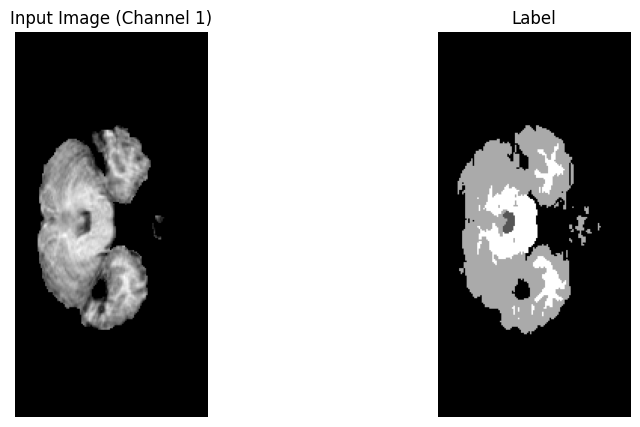

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(0.0165) metatensor(0.)


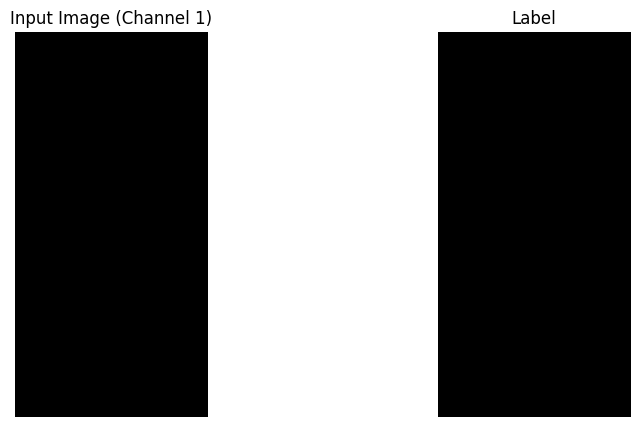

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(0.0291) metatensor(0.0392)


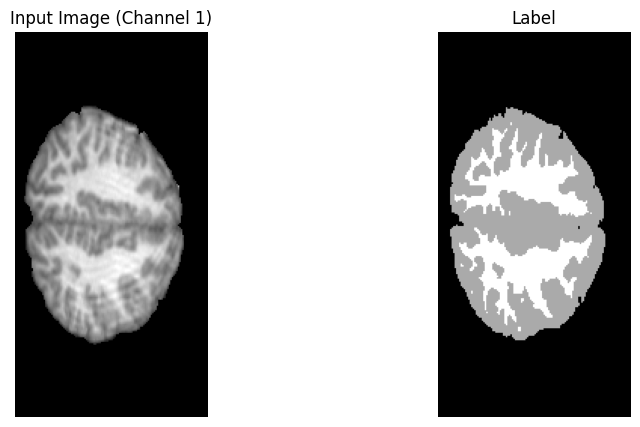

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(0.0141) metatensor(0.0225)


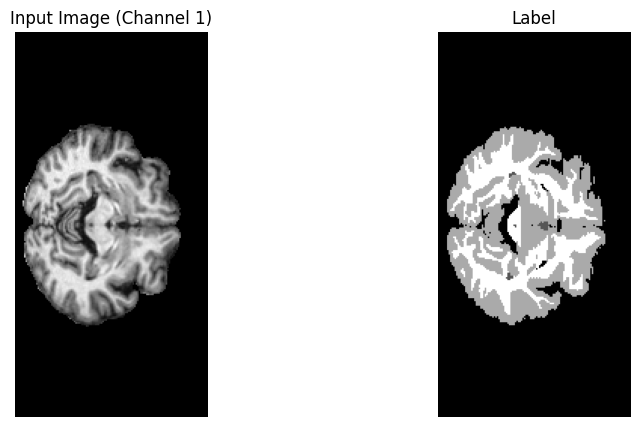

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(0.0092) metatensor(9.3133e-10)


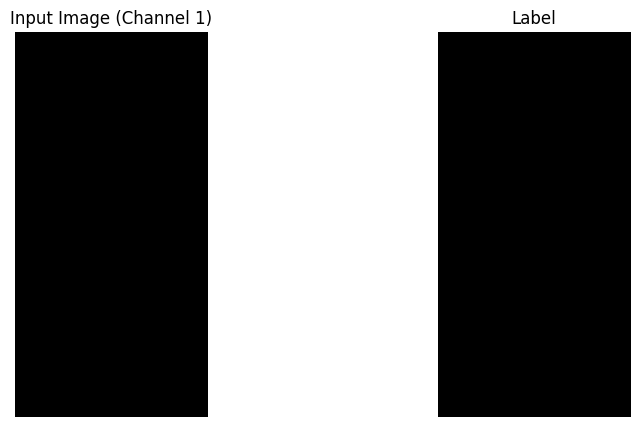

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(-0.0228) metatensor(0.0381)


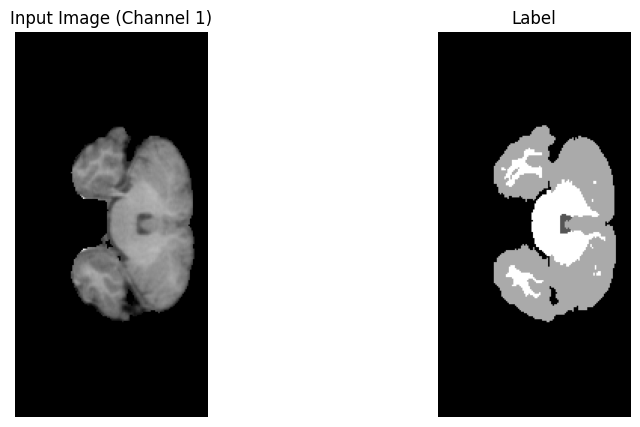

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(0.0154) metatensor(0.0315)


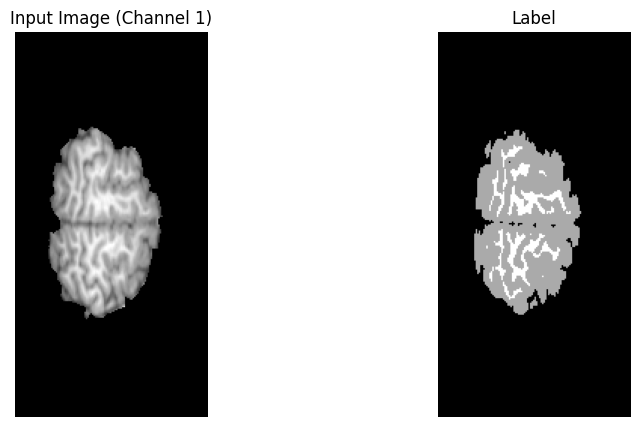

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(0.0266) metatensor(0.0414)


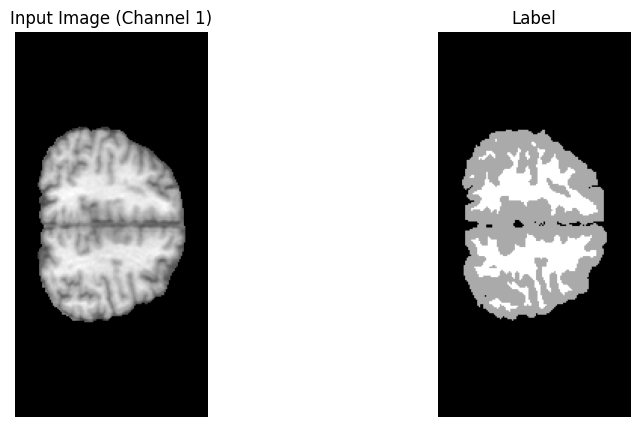

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(0.0771) metatensor(1.4901e-08)


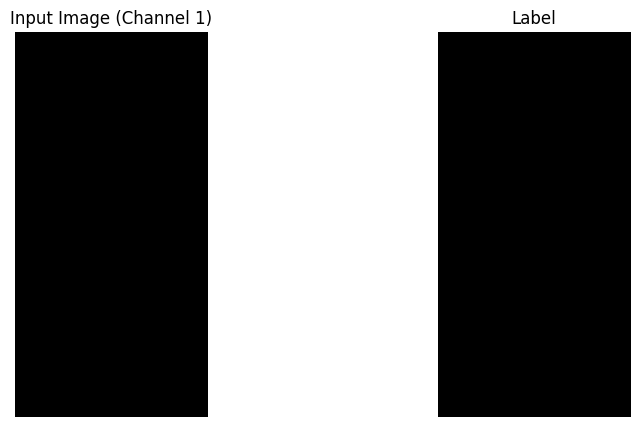

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

metatensor(2.2247e-05) metatensor(0.0010)


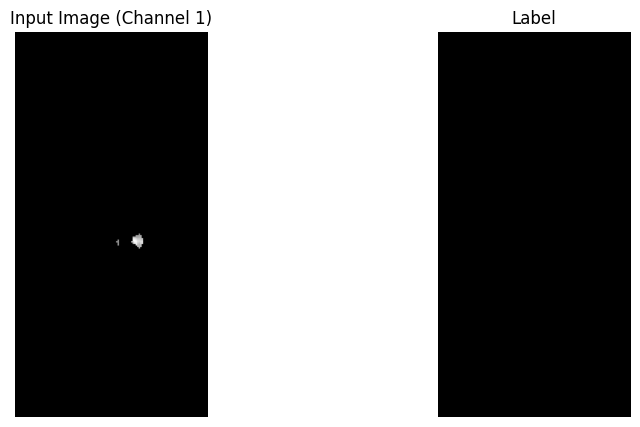

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]


In [12]:
for _ in range(10):
  epoch_iterator = tqdm(train_loader, desc=f"Epoch", dynamic_ncols=True)
  for step, batch in enumerate(epoch_iterator):
    x, y = batch
    print(x[-1].mean(), x[-1].std())
    # x = x.squeeze(-1)
    # print(x.shape, y.shape)
    # y = y.permute(0, 3, 1, 2)
    plt.figure(figsize=(10, 5))

    # Plotting x (input image) - using the first channel of the first image in the batch
    plt.subplot(1, 2, 1)
    plt.imshow(x[-1, 0, :, :].cpu().numpy(), cmap='gray')
    plt.title("Input Image (Channel 1)")
    plt.axis('off')

    # Plotting y (label) - using the first image in the batch
    plt.subplot(1, 2, 2)
    plt.imshow(y[-1, 0, :, :].cpu().numpy(), cmap='gray')
    plt.title("Label")
    plt.axis('off')

    plt.show()
    break

## Model Development

In [13]:
# Model initialization
def initialize_model(model_name):
    if model_name == "UNETR":
        model = monai.networks.nets.UNETR(
            in_channels=3,
            out_channels=4,
            img_size=(256, 256),
            feature_size=16,
            hidden_size=768,
            mlp_dim=3072,
            num_heads=12,
            norm_name="instance",
            res_block=True,
            dropout_rate=0.0,
            spatial_dims=2,
        )
    elif model_name == "ResUNet":
        model = UNet(
            spatial_dims=2,
            in_channels=3,
            out_channels=4,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
            norm="instance",
        )
    elif model_name == "ResUNetv2":
        model = UNet(
            spatial_dims=2,
            in_channels=3,
            out_channels=4,
            channels=(32, 32, 64, 128, 256, 32),
            strides=(2, 2, 2, 2, 2),
            num_res_units=4,
            norm="instance",
        )
    elif model_name == "SwinUNETR":
        model = monai.networks.nets.SwinUNETR(
            img_size=(256, 256),
            in_channels=3,
            out_channels=4,
            feature_size=48,
            use_checkpoint=True,
            spatial_dims=2,
        )
    elif model_name == "BasicUNet":
        model = monai.networks.nets.BasicUNet(
            spatial_dims=2,
            in_channels=3,
            out_channels=4,
            norm="instance",
        )
    elif model_name == "BasicUNetPP":
        model = monai.networks.nets.BasicUNetPlusPlus(
            spatial_dims=2,
            in_channels=3,
            out_channels=4,
            norm="instance",
            deep_supervision=True,
        )
    elif model_name == "DynUNet":
        model = monai.networks.nets.DynUNet(
            spatial_dims=2,
            in_channels=3,
            out_channels=4,
        )
    else:
        raise ValueError(f"Model {model_name} is not supported.")
    return model.to(device)

def plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name):
    plt.figure(figsize=(12, 6))

    # Plot losses
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_values, label='Train Loss')
    plt.plot(val_loss_values, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training and Validation Loss for {model_name}')
    plt.legend()
    plt.grid(True)


    # Plot Dice scores
    plt.subplot(1, 2, 2)
    plt.plot(train_dice_values, label='Train Dice')
    plt.plot(val_dice_values, label='Validation Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.title(f'Training and Validation Dice Score for {model_name}')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()  # Adjusts subplot parameters for a tight layout
    plt.show()

# Validation function
def validation(val_loader, model, loss_function, post_label, post_pred, dice_metric):
    model.eval()
    val_loss = 0
    val_steps = 0
    with torch.no_grad():
        for batch in val_loader:
            val_inputs, val_labels = batch
            val_inputs = val_inputs.to(device)
            val_labels = val_labels.to(device)
            val_outputs = model(val_inputs)
            # val_loss += loss_function(val_outputs, val_labels).item()
            # If deep supervision is used, val_outputs will be a list
            if isinstance(val_outputs, list):
                # Calculate loss for the final output
                val_loss += loss_function(val_outputs[-1], val_labels).item()
                val_outputs = val_outputs[-1]
            else:
                val_loss += loss_function(val_outputs, val_labels).item()
            val_labels_list = decollate_batch(val_labels)
            val_labels_convert = [post_label(val_label_tensor) for val_label_tensor in val_labels_list]
            val_outputs_list = decollate_batch(val_outputs)
            val_output_convert = [post_pred(val_pred_tensor) for val_pred_tensor in val_outputs_list]
            dice_metric(y_pred=val_output_convert, y=val_labels_convert)
            val_steps += 1
    mean_dice_val = dice_metric.aggregate().item()
    dice_metric.reset()
    mean_val_loss = val_loss / val_steps
    return mean_dice_val, mean_val_loss

# Training function
def train(train_loader, val_loader, model_name, max_epochs=50, patience=10, use_checkpoint=True):
    model = initialize_model(model_name)
    if use_checkpoint:
        print(f"Loading checkpoint for {model_name}...")
        model.load_state_dict(torch.load(os.path.join(root_dir, f"best_{model_name}_2.5Dmodel.pth")))
    print(f"Training {model_name}...")
    dice_val_best = -1
    stop_counter = 0
    # Loss function, optimizer, and scheduler
    # loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
    loss_function = DiceFocalLoss(to_onehot_y=True, softmax=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    # Metric definitions
    dice_metric = DiceMetric(include_background=True, reduction="mean", get_not_nans=False)
    post_label = AsDiscrete(to_onehot=4)
    post_pred = AsDiscrete(argmax=True, to_onehot=4)

    # Training parameters
    max_epochs = max_epochs
    early_stopping_patience = patience
    eval_num = 5
    # Metric tracking lists
    train_loss_values = []
    val_loss_values = []
    train_dice_values = []
    val_dice_values = []
    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0
        train_dice = 0
        step = 0
        epoch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", dynamic_ncols=True)
        for step, batch in enumerate(epoch_iterator):
            x, y = batch
            x = x.to(device)
            y = y.to(device)
            logit_map = model(x)
            # If deep supervision is used, logit_map will be a list
            if isinstance(logit_map, list):
                # Calculate loss for each output and sum them
                loss = sum([loss_function(output, y) for output in logit_map])
            else:
                loss = loss_function(logit_map, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Metrics calculations
            epoch_loss += loss.item()
            # If deep supervision is used, take the final output for metrics
            if isinstance(logit_map, list):
                logit_map = logit_map[-1]
            logit_map_list = decollate_batch(logit_map)
            logit_map_convert = [post_pred(pred) for pred in logit_map_list]
            y_list = decollate_batch(y)
            y_convert = [post_label(label) for label in y_list]
            dice_metric(y_pred=logit_map_convert, y=y_convert)
            train_dice += dice_metric.aggregate().item()
            dice_metric.reset()

            epoch_iterator.set_postfix(loss=loss.item())

        epoch_loss /= (step + 1)
        train_dice /= (step + 1)
        train_loss_values.append(epoch_loss)
        train_dice_values.append(train_dice)

        # Validation
        epoch_iterator_val = tqdm(val_loader, desc="Validation", dynamic_ncols=True)
        val_dice, val_loss = validation(epoch_iterator_val, model, loss_function, post_label, post_pred, dice_metric)
        val_loss_values.append(val_loss)
        val_dice_values.append(val_dice)

        # Update scheduler
        scheduler.step(val_loss)

        # Early stopping check
        if val_dice > dice_val_best:
            dice_val_best = val_dice
            stop_counter = 0
            torch.save(model.state_dict(), os.path.join(root_dir, f"best_{model_name}_2.5Dmodel.pth"))
            print(f"Epoch {epoch+1}: Model saved with dice {val_dice:.4f}")
        else:
            stop_counter += 1
            print(f"Epoch {epoch+1}: No improvement (Best dice {dice_val_best:.4f}), early stopping counter: {stop_counter}/{early_stopping_patience}")

        # Check early stopping condition
        if stop_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    # Load the best model for final evaluation
    model.load_state_dict(torch.load(os.path.join(root_dir, f"best_{model_name}_2.5Dmodel.pth")))
    return train_loss_values, val_loss_values, train_dice_values, val_dice_values

# Prediction function
def predict_volume(model, model_path, nifti_path):
    os.makedirs(output_dir, exist_ok=True)
    model.load_state_dict(torch.load(os.path.join(root_dir, model_path), map_location=device))
    # Define the transforms to apply
    transforms = Compose([
        ScaleIntensityRange(a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
        # Resize(spatial_size=(256, 256)), # only for unetr
        ToTensor(),  # Convert to tensor
    ])

    model.eval()
    volume = nib.load(nifti_path).get_fdata()
    print(f"Shape of the volume: {volume.shape}")
    prediction = np.zeros(volume.shape[:-1], dtype=np.uint8)

    with torch.no_grad():
        for slice_idx in range(volume.shape[2]):
            slice_2_5d = np.stack([
                volume[:, :, max(0, slice_idx - 1)],
                volume[:, :, slice_idx],
                volume[:, :, min(volume.shape[2] - 1, slice_idx + 1)]
            ], axis=0)  # Shape: [3, height, width]

            # Convert to tensor and apply transforms
            slice_2_5d = slice_2_5d.astype(np.float32)
            # slice_2_5d = slice_2_5d.astype(np.float32)[...,0] # for unetr

            slice_tensor = transforms(slice_2_5d)  # Apply transforms; now shape is [3, height, width]
            slice_tensor = slice_tensor.unsqueeze(0).to(device)  # Add batch dimension, shape: [1, 3, height, width]
            slice_tensor = slice_tensor.squeeze(-1)  # Remove the unnecessary singleton dimension
            # Pass the tensor through the model to get the output
            output = model(slice_tensor)  # Shape: [1, num_classes, height, width]
            if isinstance(output, list):
                # Use the final output for prediction
                output = output[-1]
            pred_class = torch.argmax(output, dim=1).cpu().numpy()  # Shape: [1, height, width]
            # pred_class = Resize((256, 128), mode='nearest')(pred_class) # only for unetr

            # Assign the predicted class slice to the prediction volume
            prediction[:, :, slice_idx] = pred_class[0]  # Assign the slice prediction

    return prediction


## Model Training

### UNet

In [ ]:
model_name = "BasicUNet"
model = initialize_model(model_name)
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=100, patience=10, use_checkpoint=False)


BasicUNet features: (32, 32, 64, 128, 256, 32).
BasicUNet features: (32, 32, 64, 128, 256, 32).
Training BasicUNet...


Validation: 100%|██████████| 20/20 [00:10<00:00,  1.83it/s]


Epoch 1: Model saved with dice 0.7027


Validation: 100%|██████████| 20/20 [00:11<00:00,  1.82it/s]


Epoch 2: Model saved with dice 0.7883


...

Epoch 55: No improvement (Best dice 0.9350), early stopping counter: 1/10


Validation: 100%|██████████| 20/20 [00:09<00:00,  2.08it/s]


Epoch 56: Model saved with dice 0.9357


Epoch 57/100:  15%|█▌        | 6/40 [00:08<00:46,  1.37s/it, loss=0.548]


KeyboardInterrupt: 

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "BasicUNet"
model = initialize_model(model_name)
model_path = "best_BasicUNet_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "BasicUNet2.5D_Val_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [11, 12, 13, 14, 17]:
    nifti_path = os.path.join(root_dir, f"Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

BasicUNet features: (32, 32, 64, 128, 256, 32).
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)


### UNETR

In [ ]:
model_name = "UNETR"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=50, patience=5, use_checkpoint=False)

Training UNETR...


Validation: 100%|██████████| 20/20 [00:26<00:00,  1.33s/it]


Epoch 1: Model saved with dice 0.6615


Validation: 100%|██████████| 20/20 [00:26<00:00,  1.33s/it]


Epoch 2: Model saved with dice 0.7612


...

Epoch 48: Model saved with dice 0.9255


Validation: 100%|██████████| 20/20 [00:27<00:00,  1.35s/it]


Epoch 49: No improvement (Best dice 0.9255), early stopping counter: 1/5


Validation: 100%|██████████| 20/20 [00:26<00:00,  1.34s/it]


Epoch 50: No improvement (Best dice 0.9255), early stopping counter: 2/5


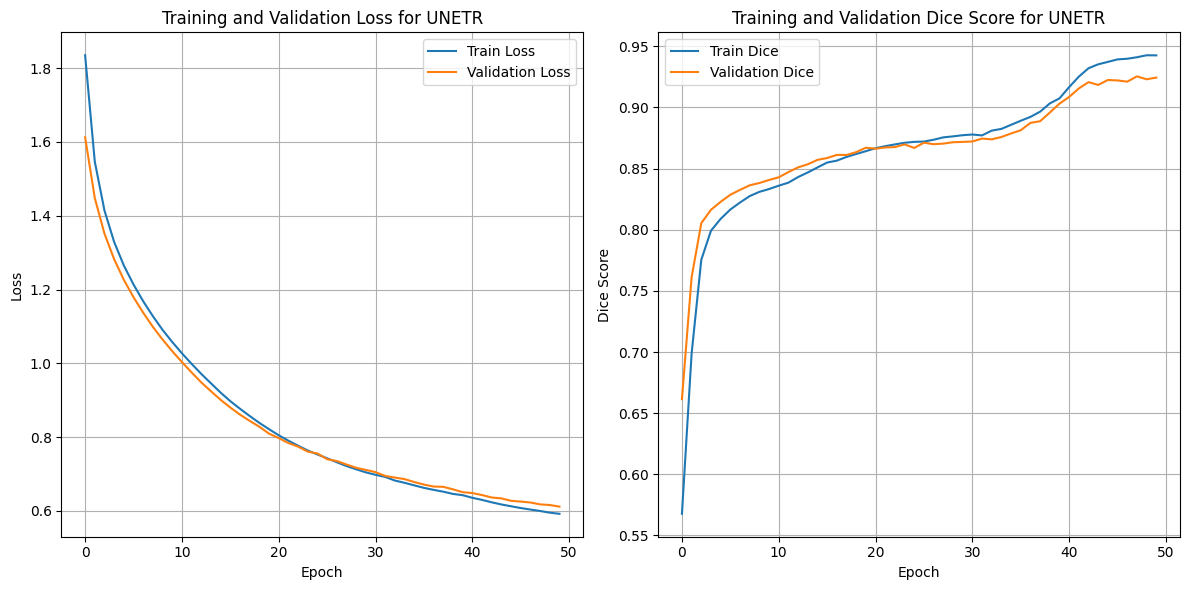

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "UNETR"
model = initialize_model(model_name)
model_path = "best_UNETR_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "UNETR2.5D_Val_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [11, 12, 13, 14, 17]:
    nifti_path = os.path.join(root_dir, f"Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

### SwinUNETR

In [ ]:
model_name = "SwinUNETR"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=150, patience=15, use_checkpoint=False)

Training SwinUNETR...


Validation: 100%|██████████| 20/20 [00:19<00:00,  1.04it/s]


Epoch 1: Model saved with dice 0.5943


Validation: 100%|██████████| 20/20 [00:18<00:00,  1.06it/s]


Epoch 2: Model saved with dice 0.7748


...

Epoch 82: No improvement (Best dice 0.9332), early stopping counter: 13/15


Validation: 100%|██████████| 20/20 [00:19<00:00,  1.02it/s]


Epoch 83: No improvement (Best dice 0.9332), early stopping counter: 14/15


Validation: 100%|██████████| 20/20 [00:19<00:00,  1.01it/s]


Epoch 84: No improvement (Best dice 0.9332), early stopping counter: 15/15
Early stopping triggered.


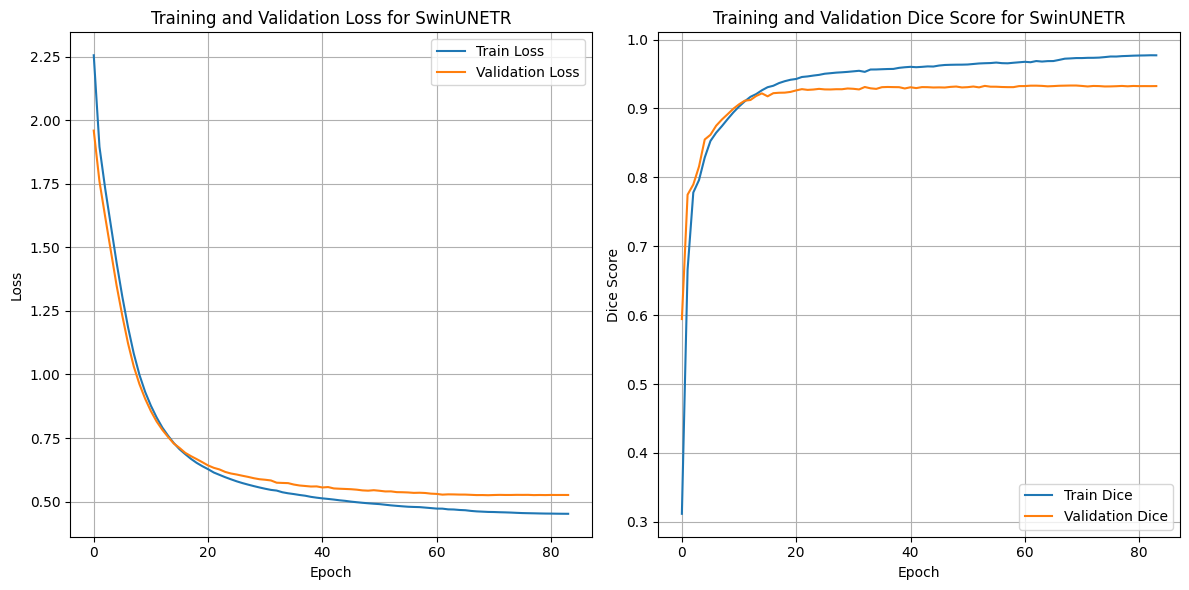

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "SwinUNETR"
model = initialize_model(model_name)
model_path = "best_SwinUNETR_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "SwinUNETR2.5D_Val_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [11, 12, 13, 14, 17]:
    nifti_path = os.path.join(root_dir, f"Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)


### ResUnet

In [ ]:
model_name = "ResUNet"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=150, patience=15, use_checkpoint=False)

Training ResUNet...


Validation: 100%|██████████| 20/20 [00:06<00:00,  3.10it/s]


Epoch 1: Model saved with dice 0.6250


Validation: 100%|██████████| 20/20 [00:06<00:00,  3.11it/s]


Epoch 2: Model saved with dice 0.6659


...

Epoch 148: No improvement (Best dice 0.9306), early stopping counter: 9/15


Validation: 100%|██████████| 20/20 [00:06<00:00,  3.06it/s]


Epoch 149: No improvement (Best dice 0.9306), early stopping counter: 10/15


Validation: 100%|██████████| 20/20 [00:06<00:00,  2.95it/s]

Epoch 150: No improvement (Best dice 0.9306), early stopping counter: 11/15


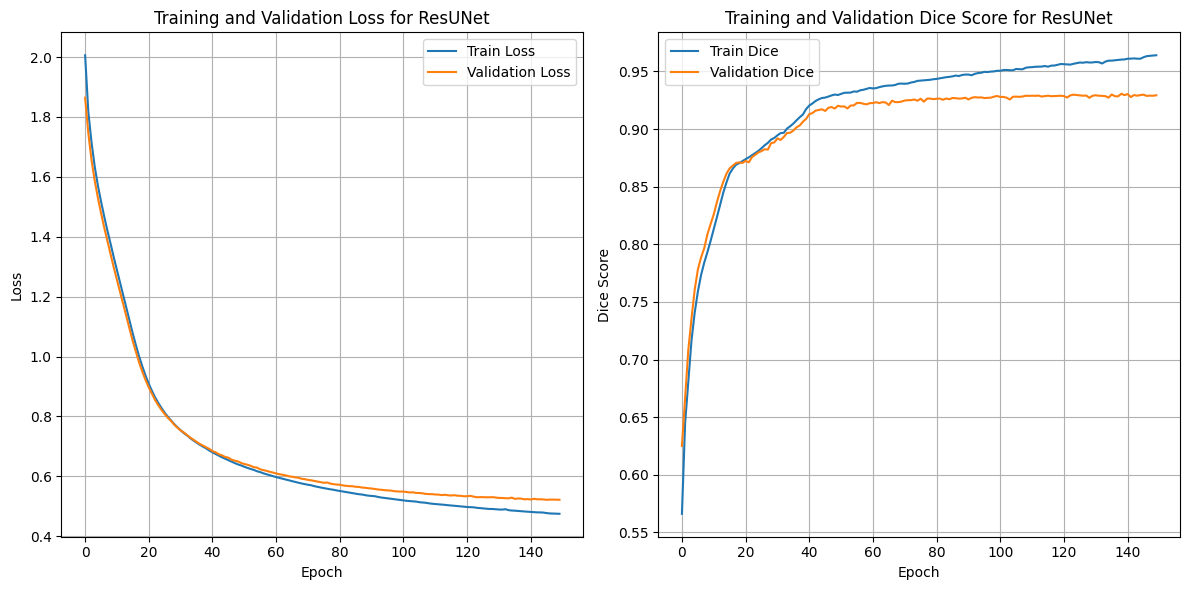

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "ResUNet"
model = initialize_model(model_name)
model_path = "best_ResUNet_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "ResUNet2.5D_Val_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [11, 12, 13, 14, 17]:
    nifti_path = os.path.join(root_dir, f"Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)


### ResUNetv2

In [ ]:
model_name = "ResUNetv2"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=150, patience=15, use_checkpoint=False)

Training ResUNetv2...


Validation: 100%|██████████| 10/10 [00:08<00:00,  1.23it/s]


Epoch 1: Model saved with dice 0.4199


Validation: 100%|██████████| 10/10 [00:08<00:00,  1.24it/s]


Epoch 2: Model saved with dice 0.4869


...

Epoch 148: Model saved with dice 0.9212


Validation: 100%|██████████| 10/10 [00:08<00:00,  1.25it/s]


Epoch 149: Model saved with dice 0.9224


Validation: 100%|██████████| 10/10 [00:08<00:00,  1.24it/s]

Epoch 150: No improvement (Best dice 0.9224), early stopping counter: 1/15


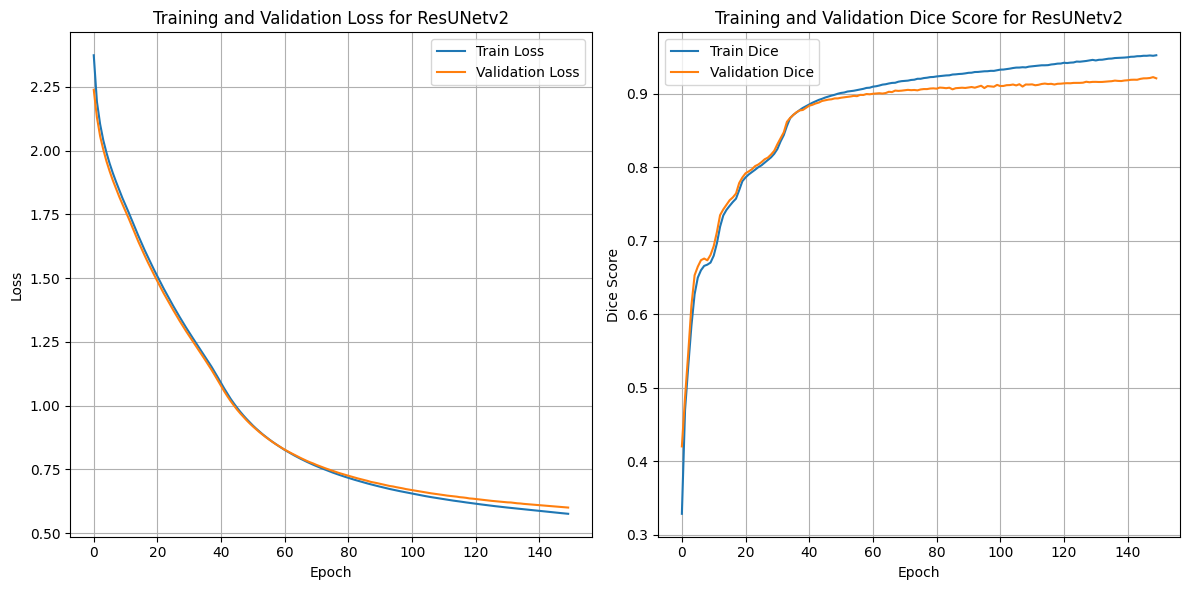

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "ResUNetv2"
model = initialize_model(model_name)
model_path = "best_ResUNetv2_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "ResUNetv22.5D_Val_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [11, 12, 13, 14, 17]:
    nifti_path = os.path.join(root_dir, f"Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)


### Unet++

In [ ]:
model_name = "BasicUNetPP"
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=100, patience=15, use_checkpoint=False)

BasicUNetPlusPlus features: (32, 32, 64, 128, 256, 32).
Training BasicUNetPP...


Validation: 100%|██████████| 20/20 [00:12<00:00,  1.59it/s]


Epoch 1: Model saved with dice 0.7928


Validation: 100%|██████████| 20/20 [00:12<00:00,  1.58it/s]


Epoch 2: Model saved with dice 0.8224


...

Epoch 96: No improvement (Best dice 0.9419), early stopping counter: 13/15


Validation: 100%|██████████| 20/20 [00:12<00:00,  1.60it/s]


Epoch 97: No improvement (Best dice 0.9419), early stopping counter: 14/15


Validation: 100%|██████████| 20/20 [00:12<00:00,  1.60it/s]

Epoch 98: No improvement (Best dice 0.9419), early stopping counter: 15/15
Early stopping triggered.


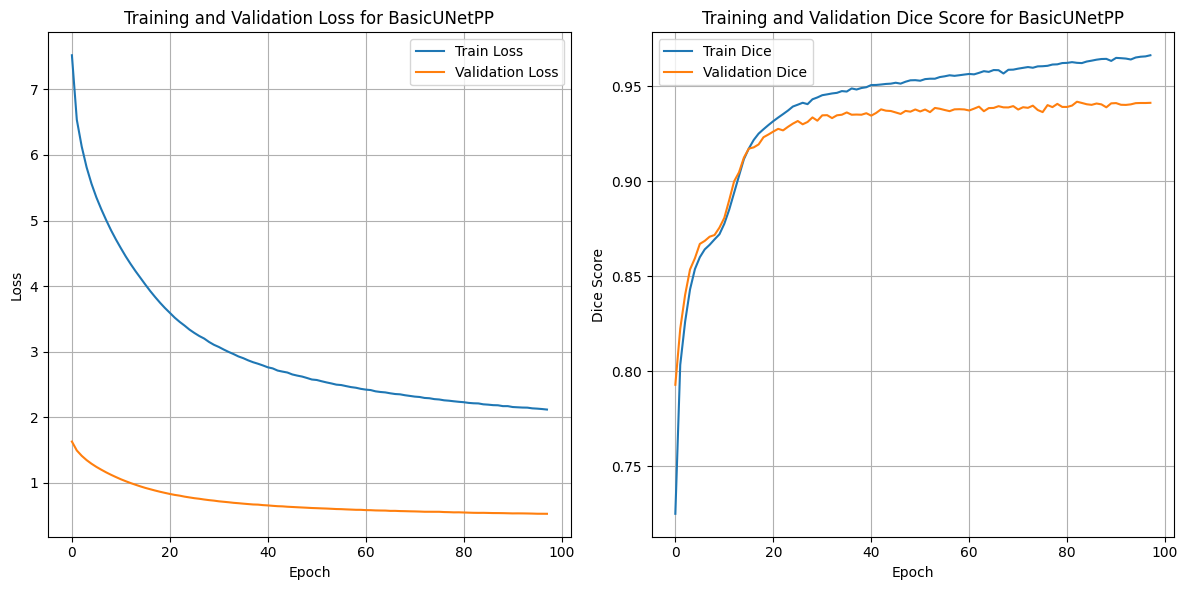

In [ ]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [ ]:
model_name = "BasicUNetPP"
model = initialize_model(model_name)
model_path = "best_BasicUNetPP_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "BasicUNetPP2.5D_Val_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [11, 12, 13, 14, 17]:
    nifti_path = os.path.join(root_dir, f"Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

BasicUNetPlusPlus features: (32, 32, 64, 128, 256, 32).
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)


### UNET + Focal Dice Loss

In [16]:
model_name = "BasicUNet"
model = initialize_model(model_name)
train_loss_values, val_loss_values, train_dice_values, val_dice_values = train(train_loader, val_loader, model_name, max_epochs=150, patience=15, use_checkpoint=False)


BasicUNet features: (32, 32, 64, 128, 256, 32).
BasicUNet features: (32, 32, 64, 128, 256, 32).
Training BasicUNet...


Validation: 100%|██████████| 20/20 [00:08<00:00,  2.45it/s]


Epoch 1: Model saved with dice 0.4761


Validation: 100%|██████████| 20/20 [00:08<00:00,  2.43it/s]


Epoch 2: Model saved with dice 0.6586


...

Epoch 148: Model saved with dice 0.9380


Validation: 100%|██████████| 20/20 [00:08<00:00,  2.47it/s]


Epoch 149: No improvement (Best dice 0.9380), early stopping counter: 1/15


Validation: 100%|██████████| 20/20 [00:08<00:00,  2.48it/s]

Epoch 150: No improvement (Best dice 0.9380), early stopping counter: 2/15


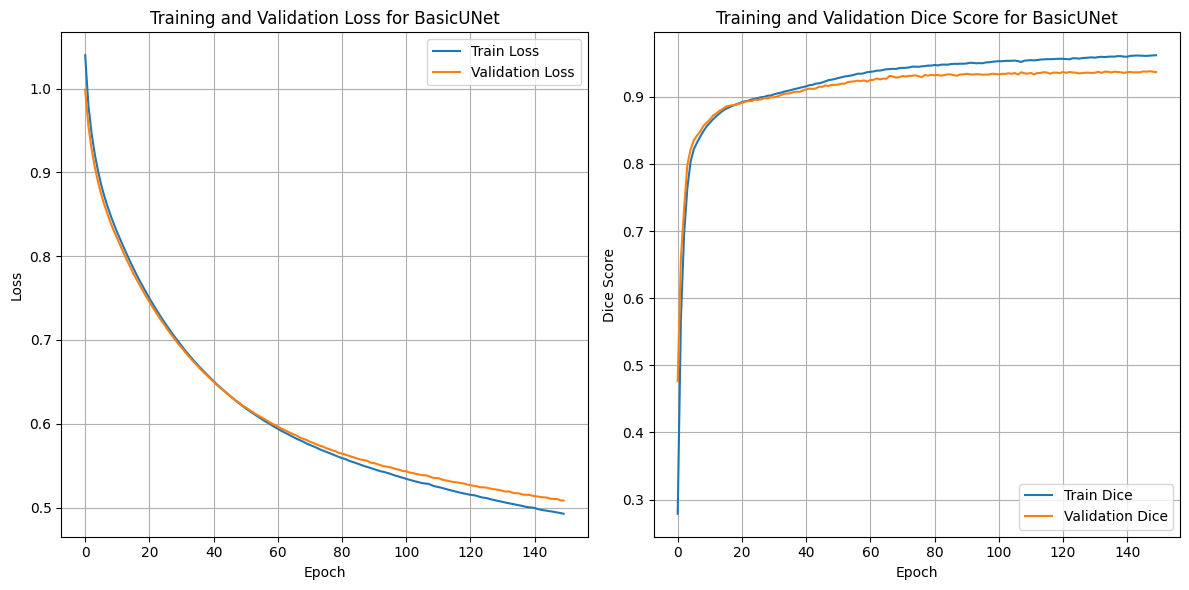

In [17]:
plot_metrics(train_loss_values, val_loss_values, train_dice_values, val_dice_values, model_name)

In [18]:
model_name = "BasicUNet"
model = initialize_model(model_name)
model_path = "best_BasicUNet_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "BasicUNet2.5D_focaldice_Val_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [11, 12, 13, 14, 17]:
    nifti_path = os.path.join(root_dir, f"Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

BasicUNet features: (32, 32, 64, 128, 256, 32).
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)


## Testing

In [ ]:
model_name = "BasicUNet"
model = initialize_model(model_name)
model_path = "best_BasicUNet_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "BasicUNet2.5D_Test_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [10, 15, '02']:
    nifti_path = os.path.join(root_dir, f"Test_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

BasicUNet features: (32, 32, 64, 128, 256, 32).
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)


In [ ]:
model_name = "SwinUNETR"
model = initialize_model(model_name)
model_path = "best_SwinUNETR_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "SwinUNETR2.5D_Test_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [10, 15, '02']:
    nifti_path = os.path.join(root_dir, f"Test_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)


In [ ]:
model_name = "ResUNet"
model = initialize_model(model_name)
model_path = "best_ResUNet_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "ResUNet2.5D_Test_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [10, 15, '02']:
    nifti_path = os.path.join(root_dir, f"Test_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5D_prediction.nii.gz"))

Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)
Shape of the volume: (256, 128, 256, 1)


In [ ]:
model_name = "UNETR"
model = initialize_model(model_name)
model_path = "best_UNETR_2.5Dmodel.pth"
output_dir = os.path.join(root_dir, "UNETR2.5D_Preds")
os.makedirs(output_dir, exist_ok=True)
for idx in [10, 15, '02']:
    nifti_path = os.path.join(root_dir, f"Test_Set/IBSR_{idx}/IBSR_{idx}.nii.gz")
    prediction = predict_volume(model, model_path, nifti_path)
    nib.save(nib.Nifti1Image(prediction, np.eye(4)), os.path.join(output_dir, f"IBSR_{idx}_2.5Dprediction.nii.gz"))

Shape of the volume: (256, 128, 256, 1)
